#-----------------------------------
# GLOBAL FEATURE EXTRACTION
#-----------------------------------

In [1]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import numpy as np
import pandas as pd
import mahotas
import cv2
import os
import h5py
import glob
import matplotlib.pyplot as plt
from PIL import Image
import warnings
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from joblib import dump, load
import random
from scipy.cluster.vq import kmeans, vq
from keras.preprocessing.image import ImageDataGenerator

pd.set_option('display.max_columns', None) 
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd 
import scipy.stats 
from scipy.stats import norm
from scipy.stats import entropy, skew
import seaborn as sns
import time

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, roc_auc_score

# Importing the required classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import ConfusionMatrixDisplay

from scipy.cluster.vq import kmeans, vq
from scipy.stats import entropy, skew
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import shannon_entropy

In [4]:
fixed_size = tuple((224, 224))
bins = 8


# Functions for feature descriptors

### 1. Hu Moments

In [5]:
# feature-descriptor-1: Hu Moments
def fd_hu_moments(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    feature = cv2.HuMoments(cv2.moments(image)).flatten()
    return feature

### 2. Haralick Textures

In [6]:
def fd_haralick(image):
    # convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # compute the haralick texture feature vector
    haralick = mahotas.features.haralick(gray).mean(axis=0)
    
    return haralick

### 3. Color Histogram

In [7]:
def fd_histogram(image, mask=None):
    # convert the image to HSV color-space
    image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # compute the color histogram
    hist  = cv2.calcHist([image], [0, 1, 2], None, [bins, bins, bins], [0, 256, 0, 256, 0, 256])
    
    # normalize the histogram
    cv2.normalize(hist, hist)
   
    return hist.flatten()

### 4. BRISK_features

In [8]:
def BRISK_features(images, k=200):
    des_list = []
    brisk = cv2.BRISK_create(30)

    for image in images:
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        kpts, des = brisk.detectAndCompute(gray_image, None)
        des_list.append((gray_image, des))  

    descriptors = des_list[0][1]
    for _, descriptor in des_list[1:]:
        descriptors = np.vstack((descriptors, descriptor))  

    descriptors_float = descriptors.astype(float) 

    voc, _ = kmeans(descriptors_float, k, 1) 

    im_features = np.zeros((len(images), k), "float32")
    for i in range(len(images)):
        words, _ = vq(des_list[i][1], voc)
        for w in words:
            im_features[i][w] += 1

    return im_features, voc

### 5. HOG_features

In [69]:
def deskew(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    m = cv2.moments(gray)
    if abs(m['mu02']) < 1e-2:
        return cv2.resize(img, fixed_size)
    
    skew = m['mu11'] / m['mu02']
    M = np.float32([[1, skew, -0.5 * fixed_size[0] * skew], [0, 1, 0]])
    img = cv2.warpAffine(img, M, fixed_size, flags=cv2.WARP_INVERSE_MAP | cv2.INTER_LINEAR)
    return img

def compute_hog_and_statistics(images):
    winSize = (128, 128)
    blockSize = (128, 128)
    blockStride = (128, 128)
    cellSize = (64, 64)
    nbins = 37

    derivAperture = 1
    winSigma = -1.
    histogramNormType = 0
    L2HysThreshold = 0.2
    gammaCorrection = 1
    nlevels = 64
    signedGradients = True

    hog = cv2.HOGDescriptor(winSize, blockSize, blockStride,
                            cellSize, nbins, derivAperture,
                            winSigma, histogramNormType, L2HysThreshold,
                            gammaCorrection, nlevels, signedGradients)

    deskewed_images = [deskew(img) for img in images]

    # Compute HOG features for each deskewed image
    hog_features = np.float32([hog.compute(img) for img in deskewed_images])

    # Flatten the HOG features to obtain histograms
    histograms = hog_features.squeeze()

    # Compute mean, median, entropy, third moment, and uniformity for each histogram
    mean_values = np.mean(histograms, axis=1)
    median_values = np.median(histograms, axis=1)
    entropy_values = np.apply_along_axis(entropy, axis=1, arr=histograms)
    third_moment_values = np.apply_along_axis(skew, axis=1, arr=histograms)
    uniformity_values = np.sum(np.square(histograms), axis=1)

    # Concatenate HOG features with computed statistics
    result = np.concatenate([hog_features, 
                             mean_values.reshape(-1, 1), 
                             median_values.reshape(-1, 1), 
                             entropy_values.reshape(-1, 1), 
                             third_moment_values.reshape(-1, 1), 
                             uniformity_values.reshape(-1, 1)], axis=1)

    return result

### 6. GLCM_features

In [10]:
def compute_glcm_features(images):
    glcm_distances = [1, 3, 5]
    glcm_angles = [0, np.pi/4, np.pi/2]

    all_features = []

    for img in images:
       
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        image_features = []

        for distance in glcm_distances:
            for angle in glcm_angles:
                GLCM = graycomatrix(gray_img, [distance], [angle])

                energy = graycoprops(GLCM, 'energy')[0]
                correlation = graycoprops(GLCM, 'correlation')[0]
                dissimilarity = graycoprops(GLCM, 'dissimilarity')[0]
                homogeneity = graycoprops(GLCM, 'homogeneity')[0]
                contrast = graycoprops(GLCM, 'contrast')[0]

                image_features.extend([energy, correlation, dissimilarity, homogeneity, contrast])

        all_features.append(image_features)

    return all_features

In [11]:
# # Function to extract features using PCA
# def extract_pca_features(image):
#     gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#     sift_descriptor = sift.compute(gray, sift.detect(gray))[1]
#     if sift_descriptor is None:
#         sift_descriptor = np.zeros((1, 128), dtype=np.float32)
#     return sift_descriptor.flatten()

### 7. Gabor features

In [12]:
def extract_gabor_features(images):
    all_mean_gabor_features = []

    for img in images:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img2 = img.reshape(-1)
        df = pd.DataFrame()
        df['Original Image'] = img2

        # Generate Gabor features
        num = 1  
        kernels = []  
        gabor_features = []  

        for theta in range(2):  # Define number of thetas. Here only 2 theta values 0 and 1/4 . pi
            theta = theta / 4. * np.pi

            for sigma in (1, 3):  # Sigma with values of 1 and 3
                for lamda in np.arange(0, np.pi, np.pi / 4):  # Range of wavelengths
                    for gamma in (0.05, 0.5):  # Gamma values of 0.05 and 0.5

                        gabor_label = 'Gabor' + str(num)  # Label Gabor columns as Gabor1, Gabor2, etc.
                        ksize = 9
                        kernel = cv2.getGaborKernel((ksize, ksize), sigma, theta, lamda, gamma, 0, ktype=cv2.CV_32F)
                        kernels.append(kernel)

                        # Now filter the image and add values to the list
                        fimg = cv2.filter2D(img2, cv2.CV_8UC3, kernel)
                        filtered_img = fimg.reshape(-1)
                        df[gabor_label] = filtered_img  
                        gabor_features.extend(filtered_img)  
                        num += 1  

        # Calculate the mean for each Gabor feature column
        mean_gabor_features = df.mean(axis=0).drop('Original Image').to_frame().T
        all_mean_gabor_features.append(mean_gabor_features)

    result_df = pd.concat(all_mean_gabor_features, ignore_index=True)

    return result_df

### 8. Contour features

In [13]:
def extract_contour_features(images):
    features_list = []

    for img in images:
        
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Canny Edge Detection 
        edges = cv2.Canny(image=gray_img, threshold1=100, threshold2=100 * 2)

        # Find contours in the binary edge image
        contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Extract features from contours
        features = []

        for contour in contours:
            # Approximate the contour to reduce the number of points
            epsilon = 0.02 * cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, epsilon, True)

            # Calculate features
            area = cv2.contourArea(approx)
            perimeter = cv2.arcLength(approx, True)
            compactness = perimeter**2 / area if area != 0 else 0
            circularity = (4 * np.pi * area) / perimeter**2 if perimeter != 0 else 0
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = w / h if h != 0 else 0
            eccentricity = np.sqrt(1 - (h**2) / (w**2)) if w > h else 0
            hull = cv2.convexHull(approx)
            hull_area = cv2.contourArea(hull)
            solidity = area / hull_area if hull_area != 0 else 0
            extent = area / (w * h) if w * h != 0 else 0
            moments = cv2.moments(approx)
            if moments['m00'] != 0:
                orientation = 0.5 * np.arctan2(2 * moments['mu11'], moments['mu20'] - moments['mu02'])
            else:
                orientation = 0
            num_sides = len(approx)
            _, radius = cv2.minEnclosingCircle(approx)
            diameter = 2 * radius

            # Append the features to the list
            features.append([area, perimeter, compactness, circularity, aspect_ratio, eccentricity,
                             solidity, extent, orientation, diameter, num_sides])

        # Convert the features list to a NumPy array
        features_array = np.array(features)

        # Calculate the mean of each feature across all contours in the image
        mean_features = np.mean(features_array, axis=0)

        # Append the mean features to the final list
        features_list.append(mean_features)

    # Convert the final list to a NumPy array
    features_array_final = np.array(features_list)

    columns = ['area', 'perimeter', 'compactness', 'circularity', 'aspect_ratio', 'eccentricity',
               'solidity', 'extent', 'orientation', 'diameter', 'num_sides']
    contour_df = pd.DataFrame(features_array_final, columns=columns)

    return contour_df

### 9. LBP_features

In [112]:
# # Function to extract features using Local Binary Pattern (LBP) for a list of images
# def extract_lbp_features_list(images):
#     lbp_features_list = []
    
#     for image in images:
#         gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#         lbp_features = mahotas.features.lbp(gray, 8, 8, ignore_zeros=True)
#         lbp_features_list.append(lbp_features.flatten())
    
#     return lbp_features_list


In [276]:
image_paths_df = pd.DataFrame(columns=['Image_Path'])

for directory_path in glob.glob(r"C:\Users\Hp\Desktop\python\Computer Vision Projects\Final Project\pop cats\CNN code\Feature Engineering\isolated_cats_output/*"):
    label = directory_path.split("\\")[-1]
    print("[STATUS] processed folder: {}".format(label))

    for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
        # Add the image path and label to the DataFrame
        new_row = {'Image_Path': img_path}
        image_paths_df = pd.concat([image_paths_df, pd.DataFrame([new_row])], ignore_index=True)

print("[STATUS] Completed Reading All Images...")

[STATUS] processed folder: Abyssinian
[STATUS] processed folder: American Shorthair
[STATUS] processed folder: Bengal
[STATUS] processed folder: Birman
[STATUS] processed folder: Bombay
[STATUS] processed folder: Egyptian Mau
[STATUS] processed folder: Maine Coon
[STATUS] processed folder: Russian Blue
[STATUS] processed folder: Scottish Fold
[STATUS] processed folder: Sphynx
[STATUS] Completed Reading All Images...


In [277]:
image_paths_df.head()

,Image_Path
0,C:\Users\Hp\Desktop\python\Computer Vision Pro...
1,C:\Users\Hp\Desktop\python\Computer Vision Pro...
2,C:\Users\Hp\Desktop\python\Computer Vision Pro...
3,C:\Users\Hp\Desktop\python\Computer Vision Pro...
4,C:\Users\Hp\Desktop\python\Computer Vision Pro...


# Extract Hu Moments, Haralick. Color Histogram  Features

### All Images

In [15]:
global_features = []
labels = []

# Iterate through each class folder
for directory_path in glob.glob(r"C:\Users\Hp\Desktop\python\Computer Vision Projects\Final Project\pop cats\CNN code\Feature Engineering\isolated_cats_output/*"):
    label = directory_path.split("\\")[-1]
    print("[STATUS] processed folder: {}".format(label))

    # Iterate through each image in the class folder
    for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
        # Read and resize the original image
        image = cv2.imread(img_path)
        image = cv2.resize(image, fixed_size)

        # Global Feature extraction
        fv_hu_moments = fd_hu_moments(image)
        fv_haralick = fd_haralick(image)
        fv_histogram = fd_histogram(image)
        


        # Concatenate global and local features
        global_feature = np.hstack([fv_histogram, fv_haralick, fv_hu_moments])
        
        global_features.append(global_feature)
        labels.append(label)

print("[STATUS] completed Global Feature Extraction...")

[STATUS] processed folder: Abyssinian
[STATUS] processed folder: American Shorthair
[STATUS] processed folder: Bengal
[STATUS] processed folder: Birman
[STATUS] processed folder: Bombay
[STATUS] processed folder: Egyptian Mau
[STATUS] processed folder: Maine Coon
[STATUS] processed folder: Russian Blue
[STATUS] processed folder: Scottish Fold
[STATUS] processed folder: Sphynx
[STATUS] completed Global Feature Extraction...


In [16]:
print("[STATUS] feature vector size {}".format(np.array(global_features).shape))

[STATUS] feature vector size (4644, 532)


In [17]:
num_global_features = len(global_features[0])

# Create column names like 'Global 1', 'Global 2', ...
column_names = [f'Global {i}' for i in range(1, num_global_features + 1)]

# Convert the list to a DataFrame with the specified column names
train_global_features = pd.DataFrame(global_features, columns=column_names)
train_global_features['Label'] = labels
train_global_features

,Global 1,Global 2,Global 3,Global 4,Global 5,Global 6,Global 7,Global 8,Global 9,Global 10,Global 11,Global 12,Global 13,Global 14,Global 15,Global 16,Global 17,Global 18,Global 19,Global 20,Global 21,Global 22,Global 23,Global 24,Global 25,Global 26,Global 27,Global 28,Global 29,Global 30,Global 31,Global 32,Global 33,Global 34,Global 35,Global 36,Global 37,Global 38,Global 39,Global 40,Global 41,Global 42,Global 43,Global 44,Global 45,Global 46,Global 47,Global 48,Global 49,Global 50,Global 51,Global 52,Global 53,Global 54,Global 55,Global 56,Global 57,Global 58,Global 59,Global 60,Global 61,Global 62,Global 63,Global 64,Global 65,Global 66,Global 67,Global 68,Global 69,Global 70,Global 71,Global 72,Global 73,Global 74,Global 75,Global 76,Global 77,Global 78,Global 79,Global 80,Global 81,Global 82,Global 83,Global 84,Global 85,Global 86,Global 87,Global 88,Global 89,Global 90,Global 91,Global 92,Global 93,Global 94,Global 95,Global 96,Global 97,Global 98,Global 99,Global 100,Global 101,Global 102,Global 103,Global 104,Global 105,Global 106,Global 107,Global 108,Global 109,Global 110,Global 111,Global 112,Global 113,Global 114,Global 115,Global 116,Global 117,Global 118,Global 119,Global 120,Global 121,Global 122,Global 123,Global 124,Global 125,Global 126,Global 127,Global 128,Global 129,Global 130,Global 131,Global 132,Global 133,Global 134,Global 135,Global 136,Global 137,Global 138,Global 139,Global 140,Global 141,Global 142,Global 143,Global 144,Global 145,Global 146,Global 147,Global 148,Global 149,Global 150,Global 151,Global 152,Global 153,Global 154,Global 155,Global 156,Global 157,Global 158,Global 159,Global 160,Global 161,Global 162,Global 163,Global 164,Global 165,Global 166,Global 167,Global 168,Global 169,Global 170,Global 171,Global 172,Global 173,Global 174,Global 175,Global 176,Global 177,Global 178,Global 179,Global 180,Global 181,Global 182,Global 183,Global 184,Global 185,Global 186,Global 187,Global 188,Global 189,Global 190,Global 191,Global 192,Global 193,Global 194,Global 195,Global 196,Global 197,Global 198,Global 199,Global 200,Global 201,Global 202,Global 203,Global 204,Global 205,Global 206,Global 207,Global 208,Global 209,Global 210,Global 211,Global 212,Global 213,Global 214,Global 215,Global 216,Global 217,Global 218,Global 219,Global 220,Global 221,Global 222,Global 223,Global 224,Global 225,Global 226,Global 227,Global 228,Global 229,Global 230,Global 231,Global 232,Global 233,Global 234,Global 235,Global 236,Global 237,Global 238,Global 239,Global 240,Global 241,Global 242,Global 243,Global 244,Global 245,Global 246,Global 247,Global 248,Global 249,Global 250,Global 251,Global 252,Global 253,Global 254,Global 255,Global 256,Global 257,Global 258,Global 259,Global 260,Global 261,Global 262,Global 263,Global 264,Global 265,Global 266,Global 267,Global 268,Global 269,Global 270,Global 271,Global 272,Global 273,Global 274,Global 275,Global 276,Global 277,Global 278,Global 279,Global 280,Global 281,Global 282,Global 283,Global 284,Global 285,Global 286,Global 287,Global 288,Global 289,Global 290,Global 291,Global 292,Global 293,Global 294,Global 295,Global 296,Global 297,Global 298,Global 299,Global 300,Global 301,Global 302,Global 303,Global 304,Global 305,Global 306,Global 307,Global 308,Global 309,Global 310,Global 311,Global 312,Global 313,Global 314,Global 315,Global 316,Global 317,Global 318,Global 319,Global 320,Global 321,Global 322,Global 323,Global 324,Global 325,Global 326,Global 327,Global 328,Global 329,Global 330,Global 331,Global 332,Global 333,Global 334,Global 335,Global 336,Global 337,Global 338,Global 339,Global 340,Global 341,Global 342,Global 343,Global 344,Global 345,Global 346,Global 347,Global 348,Global 349,Global 350,Global 351,Global 352,Global 353,Global 354,Global 355,Global 356,Global 357,Global 358,Global 359,Global 360,Global 361,Global 362,Global 363,Global 364,Global 365,Global 366,Global 367,Global 368,Global 369,Global 370,Global 371,Global 372,Global 373,Glob

In [38]:
# Identify the columns to drop
columns_to_drop = [f'Global {i}' for i in range(385, 513)]

# Drop the identified columns
global_features_df = train_global_features.drop(columns=columns_to_drop)

In [39]:
global_features_df.shape

(4644, 405)

#### Save the Global Features to a CSV file

In [40]:
# Save the DataFrame to a CSV file
global_features_df.to_csv('global_features_iso.csv', index=False)

# Extract Contour Features

### All Images

In [22]:
all_images = []
all_labels = [] 
#for directory_path in glob.glob("cell_images/train/*"):
for directory_path in glob.glob(r"C:\Users\Hp\Desktop\python\Computer Vision Projects\Final Project\pop cats\CNN code\Feature Engineering\isolated_cats_output/*"):
    label = directory_path.split("\\")[-1]
    print("[STATUS] processed folder: {}".format(label))
    
    for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
       
        image = cv2.imread(img_path)
        image = cv2.resize(image, fixed_size)

        all_images.append(image)
        all_labels.append(label)
        
print("[STATUS] completed Reading All Images...")

[STATUS] processed folder: Abyssinian
[STATUS] processed folder: American Shorthair
[STATUS] processed folder: Bengal
[STATUS] processed folder: Birman
[STATUS] processed folder: Bombay
[STATUS] processed folder: Egyptian Mau
[STATUS] processed folder: Maine Coon
[STATUS] processed folder: Russian Blue
[STATUS] processed folder: Scottish Fold
[STATUS] processed folder: Sphynx
[STATUS] completed Reading All Images...


In [23]:
all_images = np.array(all_images)
all_labels = np.array(all_labels)

In [24]:
contour_features = extract_contour_features(all_images)

In [25]:
contour_features.shape

(4644, 11)

#### Save the Contour Features to a CSV file

In [26]:
# Save the DataFrame to a CSV file
contour_features.to_csv('contour_features_iso.csv', index=False)

# Extract BRISK Features

### All Images

In [121]:
train_brisk_features = BRISK_features(all_images)

In [123]:
column_prefix77 = 'Brisk'

# Extract the NumPy array from the tuple
brisk_array = train_brisk_features[0]

# Generate column names
num_features77 = brisk_array.shape[1]
column_names77 = [f'{column_prefix77} {i+1}' for i in range(num_features77)]

# Convert NumPy array to DataFrame
brisk_df = pd.DataFrame(brisk_array, columns=column_names77)


In [124]:
brisk_df.shape

(4644, 200)

In [126]:
brisk_df.head()

,Brisk 1,Brisk 2,Brisk 3,Brisk 4,Brisk 5,Brisk 6,Brisk 7,Brisk 8,Brisk 9,Brisk 10,Brisk 11,Brisk 12,Brisk 13,Brisk 14,Brisk 15,Brisk 16,Brisk 17,Brisk 18,Brisk 19,Brisk 20,Brisk 21,Brisk 22,Brisk 23,Brisk 24,Brisk 25,Brisk 26,Brisk 27,Brisk 28,Brisk 29,Brisk 30,Brisk 31,Brisk 32,Brisk 33,Brisk 34,Brisk 35,Brisk 36,Brisk 37,Brisk 38,Brisk 39,Brisk 40,Brisk 41,Brisk 42,Brisk 43,Brisk 44,Brisk 45,Brisk 46,Brisk 47,Brisk 48,Brisk 49,Brisk 50,Brisk 51,Brisk 52,Brisk 53,Brisk 54,Brisk 55,Brisk 56,Brisk 57,Brisk 58,Brisk 59,Brisk 60,Brisk 61,Brisk 62,Brisk 63,Brisk 64,Brisk 65,Brisk 66,Brisk 67,Brisk 68,Brisk 69,Brisk 70,Brisk 71,Brisk 72,Brisk 73,Brisk 74,Brisk 75,Brisk 76,Brisk 77,Brisk 78,Brisk 79,Brisk 80,Brisk 81,Brisk 82,Brisk 83,Brisk 84,Brisk 85,Brisk 86,Brisk 87,Brisk 88,Brisk 89,Brisk 90,Brisk 91,Brisk 92,Brisk 93,Brisk 94,Brisk 95,Brisk 96,Brisk 97,Brisk 98,Brisk 99,Brisk 100,Brisk 101,Brisk 102,Brisk 103,Brisk 104,Brisk 105,Brisk 106,Brisk 107,Brisk 108,Brisk 109,Brisk 110,Brisk 111,Brisk 112,Brisk 113,Brisk 114,Brisk 115,Brisk 116,Brisk 117,Brisk 118,Brisk 119,Brisk 120,Brisk 121,Brisk 122,Brisk 123,Brisk 124,Brisk 125,Brisk 126,Brisk 127,Brisk 128,Brisk 129,Brisk 130,Brisk 131,Brisk 132,Brisk 133,Brisk 134,Brisk 135,Brisk 136,Brisk 137,Brisk 138,Brisk 139,Brisk 140,Brisk 141,Brisk 142,Brisk 143,Brisk 144,Brisk 145,Brisk 146,Brisk 147,Brisk 148,Brisk 149,Brisk 150,Brisk 151,Brisk 152,Brisk 153,Brisk 154,Brisk 155,Brisk 156,Brisk 157,Brisk 158,Brisk 159,Brisk 160,Brisk 161,Brisk 162,Brisk 163,Brisk 164,Brisk 165,Brisk 166,Brisk 167,Brisk 168,Brisk 169,Brisk 170,Brisk 171,Brisk 172,Brisk 173,Brisk 174,Brisk 175,Brisk 176,Brisk 177,Brisk 178,Brisk 179,Brisk 180,Brisk 181,Brisk 182,Brisk 183,Brisk 184,Brisk 185,Brisk 186,Brisk 187,Brisk 188,Brisk 189,Brisk 190,Brisk 191,Brisk 192,Brisk 193,Brisk 194,Brisk 195,Brisk 196,Brisk 197,Brisk 198,Brisk 199,Brisk 200
0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,1.0,0.0,2.0,1.0,2.0,0.0,0.0,1.0,9.0,2.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,2.0,7.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,3.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,3.0,0.0,2.0,0.0,2.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,4.0,6.0,3.0,0.0,2.0,2.0,10.0,8.0,7.0,5.0,2.0,2.0,1.0,6.0,1.0,7.0,6.0,6.0,4.0,1.0,1.0,3.0,0.0,6.0,6.0,3.0,4.0,1.0,3.0,4.0,2.0,1.0,1.0,1.0,4.0,4.0,7.0,8.0,2.0,3.0,1.0,1.0,4.0,0.0,7.0,4.0,1.0,2.0,6.0,4.0,1.0,9.0,2.0,0.0,8.0,4.0,0.0,7.0,3.0,7.0,5.0,0.0,7.0,5.0,5.0,4.0,1.0,4.0,0.0,2.0,5.0,1.0,9.0,7.0,11.0,5.0,3.0,12.0,9.0,1.0,9.0,1.0,0.0,6.0,0.0,8.0,3.0,2.0,3.0,2.0,4.0,2.0,3.0,2.0,2.0,0.0,0.0,3.0,4.0,3.0,0.0,7.0,4.0,11.0,3.0,2.0,4.0,5.0,1.0,2.0,4.0,5.0,2.0,1.0,2.0,7.0,5.0,1.0,2.0,4.0,0.0,9.0,9.0,0.0,3.0,4.0,2.0,2.0,0.0,8.0,1.0,1.0,7.0,2.0,6.0,2.0,8.0,2.0,3.0,1.0,0.0,5.0,1.0,7.0,1.0,2.0,4.0,3.0,1.0,1.0,3.0,6.0,4.0,6.0,4.0,9.0,2.0,5.0,1.0,4.0,3.0,2.0,2.0,4.0,2.0,2.0,2.0,7.0,2.0,4.0,3.0,6.0,1.0,8.0,6.0,6.0,3.0,8.0,0.0,0.0,3.0,3.0,2.0,1.0,5.0,10.0,2.0,0.0,4.0,4.0,2.0,3.0,6.0,5.0,0.0,3.0,1.0,3.0,5.0,3.0
2,3.0,5.0,2.0,3.0,2.0,4.0,5.0,2.0,3.0,2.0,14.0,0.0,8.0,1.0,3.0,5.0,13.0,1.0,12.0,3.0,3.0,0.0,5.0,5.0,2.0,5.0,8.0,4.0,3.0,3.0,4.0,2.0,8.0,0.0,0.0,3.0,1.0,7.0,2.0,0.0,3.0,3.0,2.0,3.0,5.0,9.0,9.0,12.0,1.0,3.0,2.0,5.0,0.0,11.0,7.0,4.0,1.0,5.0,2.0,7.0,2.0,10.0,8.0,4.0,3.0,2.0,6.0,4.0,0.0,2.0,4.0,1.0,5.0,3.0,7.0,5.0,4.0,6.0,3.0,1.0,8.0,4.0,1.0,4.0,9.0,5.0,7.0,7.0,9.0,11.0,8.0,9.0,4.0,4.0,6.0,1.0,2.0,2.0,1.0,2.0,4.0,8.0,4.0,13.0,2.0,2.0,8.0,6.0,1.0,6.0,4.0,10.0,3.0,2.0,1.0,3.0,8.0,7.0,0.0,2.0,2.0,4.0

#### Save the BRISK Features to a CSV file

In [125]:
# Save the DataFrame to a CSV file
brisk_df.to_csv('BRISK_features_iso.csv', index=False)

# Extract HOG Features

### All Images

In [74]:
hog_features = compute_hog_and_statistics(all_images)

In [75]:
column_prefix = 'Hog'

# Generate column names
num_features = hog_features.shape[1]
column_names = [f'{column_prefix}{i+1}' for i in range(num_features)]

# Convert NumPy array to DataFrame
hog_features_df = pd.DataFrame(hog_features, columns=column_names)

In [76]:
hog_features_df.shape

(4644, 597)

In [77]:
hog_features_df

,Hog1,Hog2,Hog3,Hog4,Hog5,Hog6,Hog7,Hog8,Hog9,Hog10,Hog11,Hog12,Hog13,Hog14,Hog15,Hog16,Hog17,Hog18,Hog19,Hog20,Hog21,Hog22,Hog23,Hog24,Hog25,Hog26,Hog27,Hog28,Hog29,Hog30,Hog31,Hog32,Hog33,Hog34,Hog35,Hog36,Hog37,Hog38,Hog39,Hog40,Hog41,Hog42,Hog43,Hog44,Hog45,Hog46,Hog47,Hog48,Hog49,Hog50,Hog51,Hog52,Hog53,Hog54,Hog55,Hog56,Hog57,Hog58,Hog59,Hog60,Hog61,Hog62,Hog63,Hog64,Hog65,Hog66,Hog67,Hog68,Hog69,Hog70,Hog71,Hog72,Hog73,Hog74,Hog75,Hog76,Hog77,Hog78,Hog79,Hog80,Hog81,Hog82,Hog83,Hog84,Hog85,Hog86,Hog87,Hog88,Hog89,Hog90,Hog91,Hog92,Hog93,Hog94,Hog95,Hog96,Hog97,Hog98,Hog99,Hog100,Hog101,Hog102,Hog103,Hog104,Hog105,Hog106,Hog107,Hog108,Hog109,Hog110,Hog111,Hog112,Hog113,Hog114,Hog115,Hog116,Hog117,Hog118,Hog119,Hog120,Hog121,Hog122,Hog123,Hog124,Hog125,Hog126,Hog127,Hog128,Hog129,Hog130,Hog131,Hog132,Hog133,Hog134,Hog135,Hog136,Hog137,Hog138,Hog139,Hog140,Hog141,Hog142,Hog143,Hog144,Hog145,Hog146,Hog147,Hog148,Hog149,Hog150,Hog151,Hog152,Hog153,Hog154,Hog155,Hog156,Hog157,Hog158,Hog159,Hog160,Hog161,Hog162,Hog163,Hog164,Hog165,Hog166,Hog167,Hog168,Hog169,Hog170,Hog171,Hog172,Hog173,Hog174,Hog175,Hog176,Hog177,Hog178,Hog179,Hog180,Hog181,Hog182,Hog183,Hog184,Hog185,Hog186,Hog187,Hog188,Hog189,Hog190,Hog191,Hog192,Hog193,Hog194,Hog195,Hog196,Hog197,Hog198,Hog199,Hog200,Hog201,Hog202,Hog203,Hog204,Hog205,Hog206,Hog207,Hog208,Hog209,Hog210,Hog211,Hog212,Hog213,Hog214,Hog215,Hog216,Hog217,Hog218,Hog219,Hog220,Hog221,Hog222,Hog223,Hog224,Hog225,Hog226,Hog227,Hog228,Hog229,Hog230,Hog231,Hog232,Hog233,Hog234,Hog235,Hog236,Hog237,Hog238,Hog239,Hog240,Hog241,Hog242,Hog243,Hog244,Hog245,Hog246,Hog247,Hog248,Hog249,Hog250,Hog251,Hog252,Hog253,Hog254,Hog255,Hog256,Hog257,Hog258,Hog259,Hog260,Hog261,Hog262,Hog263,Hog264,Hog265,Hog266,Hog267,Hog268,Hog269,Hog270,Hog271,Hog272,Hog273,Hog274,Hog275,Hog276,Hog277,Hog278,Hog279,Hog280,Hog281,Hog282,Hog283,Hog284,Hog285,Hog286,Hog287,Hog288,Hog289,Hog290,Hog291,Hog292,Hog293,Hog294,Hog295,Hog296,Hog297,Hog298,Hog299,Hog300,Hog301,Hog302,Hog303,Hog304,Hog305,Hog306,Hog307,Hog308,Hog309,Hog310,Hog311,Hog312,Hog313,Hog314,Hog315,Hog316,Hog317,Hog318,Hog319,Hog320,Hog321,Hog322,Hog323,Hog324,Hog325,Hog326,Hog327,Hog328,Hog329,Hog330,Hog331,Hog332,Hog333,Hog334,Hog335,Hog336,Hog337,Hog338,Hog339,Hog340,Hog341,Hog342,Hog343,Hog344,Hog345,Hog346,Hog347,Hog348,Hog349,Hog350,Hog351,Hog352,Hog353,Hog354,Hog355,Hog356,Hog357,Hog358,Hog359,Hog360,Hog361,Hog362,Hog363,Hog364,Hog365,Hog366,Hog367,Hog368,Hog369,Hog370,Hog371,Hog372,Hog373,Hog374,Hog375,Hog376,Hog377,Hog378,Hog379,Hog380,Hog381,Hog382,Hog383,Hog384,Hog385,Hog386,Hog387,Hog388,Hog389,Hog390,Hog391,Hog392,Hog393,Hog394,Hog395,Hog396,Hog397,Hog398,Hog399,Hog400,Hog401,Hog402,Hog403,Hog404,Hog405,Hog406,Hog407,Hog408,Hog409,Hog410,Hog411,Hog412,Hog413,Hog414,Hog415,Hog416,Hog417,Hog418,Hog419,Hog420,Hog421,Hog422,Hog423,Hog424,Hog425,Hog426,Hog427,Hog428,Hog429,Hog430,Hog431,Hog432,Hog433,Hog434,Hog435,Hog436,Hog437,Hog438,Hog439,Hog440,Hog441,Hog442,Hog443,Hog444,Hog445,Hog446,Hog447,Hog448,Hog449,Hog450,Hog451,Hog452,Hog453,Hog454,Hog455,Hog456,Hog457,Hog458,Hog459,Hog460,Hog461,Hog462,Hog463,Hog464,Hog465,Hog466,Hog467,Hog468,Hog469,Hog470,Hog471,Hog472,Hog473,Hog474,Hog475,Hog476,Hog477,Hog478,Hog479,Hog480,Hog481,Hog482,Hog483,Hog484,Hog485,Hog486,Hog487,Hog488,Hog489,Hog490,Hog491,Hog492,Hog493,Hog494,Hog495,Hog496,Hog497,Hog498,Hog499,Hog500,Hog501,Hog502,Hog503,Hog504,Hog505,Hog506,Hog507,Hog508,Hog509,Hog510,Hog511,Hog512,Hog513,Hog514,Hog515,Hog516,Hog517,Hog518,Hog519,Hog520,Hog521,Hog522,Hog523,Hog524,Hog525,Hog526,Hog527,Hog528,Hog529,Hog530,Hog531,Hog532,Hog533,Hog534,Hog535,Hog536,Hog537,Hog538,Hog539,Hog540,Hog541,Hog542,Hog543,Hog544,Hog545,Hog546,Hog547,Hog548,Hog549,Hog550,Hog551,Hog552,Hog553,Hog554,Hog555,Hog556,Hog557,Hog558,Hog559,Hog560,Hog561,Hog562,Hog563,Hog564,Hog565,Hog566,Hog567,Hog568,Hog569,Hog570,Hog571,Hog572,Hog573,Hog574,Hog575,Hog576,Hog577,Hog578,Hog579,Hog580,Hog581,Hog582,Hog583,Hog584,Hog585,Hog586,Hog58

#### Save the HOG Features to a CSV file

In [78]:
# Save the DataFrame to a CSV file
hog_features_df.to_csv('hog_features_iso.csv', index=False)

# Extract GLMC Features

### All Images

In [29]:
glcm_features = compute_glcm_features(all_images)

In [30]:
glcm_features_array = np.array(glcm_features)

# Flatten the nested arrays in train_glcm_features_array
flattened_features = glcm_features_array.reshape(glcm_features_array.shape[0], -1)

# Replace 'Glmc' with the actual prefix you want for the column names
column_prefix2 = 'Glmc'

# Generate column names
num_features2 = flattened_features.shape[1]
column_names2 = [f'{column_prefix2}{i+1}' for i in range(num_features2)]

# Convert NumPy array to DataFrame
glcm_features_df = pd.DataFrame(flattened_features, columns=column_names2)
glcm_features_df

,Glmc1,Glmc2,Glmc3,Glmc4,Glmc5,Glmc6,Glmc7,Glmc8,Glmc9,Glmc10,Glmc11,Glmc12,Glmc13,Glmc14,Glmc15,Glmc16,Glmc17,Glmc18,Glmc19,Glmc20,Glmc21,Glmc22,Glmc23,Glmc24,Glmc25,Glmc26,Glmc27,Glmc28,Glmc29,Glmc30,Glmc31,Glmc32,Glmc33,Glmc34,Glmc35,Glmc36,Glmc37,Glmc38,Glmc39,Glmc40,Glmc41,Glmc42,Glmc43,Glmc44,Glmc45
0,0.597774,0.983395,3.477178,0.692508,128.025384,0.594527,0.979467,4.134388,0.674420,158.732108,0.601628,0.993832,2.170464,0.716402,47.555834,0.586700,0.932346,8.167421,0.640219,524.368213,0.586916,0.950798,7.005052,0.644168,382.338061,0.592918,0.970224,5.229456,0.660301,230.792562,0.576097,0.883087,11.668216,0.618301,910.923271,0.571136,0.897486,11.334008,0.611238,804.783264,0.585208,0.948083,7.419398,0.640500,404.353311
1,0.772524,0.849336,6.494275,0.788394,414.598695,0.769758,0.834511,7.002554,0.784431,457.065696,0.771544,0.848666,6.570307,0.787305,416.443185,0.764931,0.748163,8.950145,0.776696,698.139261,0.764044,0.764373,8.700998,0.776780,655.582745,0.762083,0.747040,9.088276,0.773794,701.251454,0.756548,0.680079,10.642286,0.767644,893.490134,0.751038,0.680666,10.861488,0.761621,901.680661,0.751595,0.673934,10.891267,0.761854,910.650603
2,0.555911,0.917458,8.790038,0.600500,495.672245,0.551951,0.913574,9.465704,0.591290,520.107824,0.556011,0.924685,8.421925,0.600173,452.273182,0.543342,0.857633,12.980567,0.572775,858.609648,0.542361,0.871573,12.329762,0.573692,776.166748,0.544292,0.872632,12.333751,0.574585,768.153038,0.529899,0.810182,15.950995,0.554908,1149.684442,0.521980,0.810379,16.471942,0.546089,1155.631983,0.531552,0.828906,15.210820,0.556480,1036.277764
3,0.464149,0.979372,5.020600,0.560294,152.677871,0.459012,0.963579,6.711315,0.538693,269.931086,0.462969,0.974238,5.674488,0.553416,190.625200,0.453517,0.920092,10.699337,0.511707,592.534300,0.449649,0.918400,10.496591,0.512489,606.172673,0.451555,0.906994,11.330337,0.510724,690.083407,0.443166,0.868518,14.662590,0.490732,975.957110,0.432701,0.841127,16.246178,0.479714,1184.484773,0.440845,0.850813,15.359711,0.489164,1109.690232
4,0.377697,0.969776,6.330417,0.503414,292.445047,0.373755,0.963593,7.643065,0.482611,352.209214,0.382962,0.989024,4.450012,0.532314,106.151325,0.361723,0.878433,15.015110,0.438974,1179.194530,0.363031,0.912915,12.710271,0.445565,843.201587,0.370125,0.946464,10.521493,0.462041,517.676471,0.350055,0.801894,21.115460,0.412097,1927.035021,0.344809,0.827029,19.930950,0.407567,1677.239091,0.362462,0.908322,14.374857,0.438327,886.456234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4639,0.814919,0.961197,2.616772,0.855687,234.987648,0.811858,0.940342,3.754570,0.843119,362.595488,0.815358,0.966779,2.610466,0.853242,201.181094,0.806815,0.890840,5.968184,0.828633,665.840922,0.804556,0.888820,6.186815,0.827769,680.665672,0.806779,0.906669,5.670410,0.828874,569.336538,0.797512,0.827532,8.725946,0.814435,1059.489033,0.788618,0.790844,10.543843,0.805081,1299.026860,0.797962,0.847591,8.327116,0.814841,936.573324
4640,0.784248,0.970207,3.257247,0.813686,171.354020,0.782114,0.963106,3.757646,0.808974,212.955539,0.785069,0.980769,2.500120,0.822942,110.610706,0.775163,0.901156,6.837670,0.791250,572.586983,0.775499,0.923661,5.981292,0.794182,443.786259,0.777970,0.933846,5.400372,0.798163,383.221437,0.765202,0.833998,9.807037,0.777285,968.573589,0.761235,0.846333,9.679587,0.773752,906.177273,0.770073,0.888827,7.640003,0.785148,648.661693
4641,0.725964,0.973909,3.267437,0.778101,206.501221,0.723003,0.955767,4.780772,0.760049,351.137545,0.724399,0.964062,4.156310,0.764569,284.978740,0.720348,0.929156,6.826580,0.749858,562.239112,0.717252,0.918171,7.460170,0.742881,652.395078,0.714188,0.899434,8.693399,0.733983,802.459922,0.714105,0.892748,9.371677,0.735876,853.716793,0.704280,0.850034,11.997025,0.720619,1206.177686,0.703243,0.840449,12.465468,0.716596,1281.132828
4642,0.526208,0.976833,4.606262,0.631788,257.810138,0.523725,0.

In [32]:
glcm_features_df.shape

(4644, 45)

#### Save the GLCM Features to a CSV file

In [79]:
# Save the DataFrame to a CSV file
glcm_features_df.to_csv('glcm_features_iso.csv', index=False)

# Extract Gabor Features

#### All Images

In [33]:
gabor_features = extract_gabor_features(all_images)

In [34]:
gabor_features.shape

(4644, 32)

In [35]:
gabor_features_df = gabor_features.drop(columns=['Gabor1','Gabor2','Gabor9','Gabor10','Gabor13','Gabor14','Gabor15','Gabor16','Gabor17','Gabor18', 'Gabor25', 'Gabor26'])

In [36]:
gabor_features_df

,Gabor3,Gabor4,Gabor5,Gabor6,Gabor7,Gabor8,Gabor11,Gabor12,Gabor19,Gabor20,Gabor21,Gabor22,Gabor23,Gabor24,Gabor27,Gabor28,Gabor29,Gabor30,Gabor31,Gabor32
0,90.434730,78.861567,63.562400,36.269252,26.750777,14.675163,84.408522,82.539361,97.528500,91.670619,23.846241,0.261260,70.695871,14.632573,95.058434,92.572007,18.658123,9.831334,33.488401,20.079540
1,53.579540,39.935009,25.822804,14.267558,10.525072,5.776008,46.377910,44.089744,59.892100,55.277563,9.458068,0.100925,30.442443,5.774195,58.144093,56.051419,7.620974,4.085599,13.671915,8.457769
2,107.304767,91.149773,64.354153,35.777683,26.391940,14.484096,99.653161,96.915637,115.442223,109.044244,23.608279,0.278161,74.647341,14.442064,112.716618,109.983239,18.698960,9.917032,33.411372,20.227978
3,121.878488,103.638373,78.984534,44.398497,32.746193,17.965402,112.277922,109.259965,131.028958,124.796716,29.184172,0.315210,89.808056,17.900151,128.547692,125.684511,22.819176,12.018854,40.947465,24.517698
4,139.791075,119.148976,90.182697,53.484495,39.446787,21.643176,130.008151,126.493642,150.061065,141.634407,35.171915,0.397620,102.149294,21.579221,146.824119,142.878627,27.525271,14.502651,49.401905,29.635623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4639,48.486268,44.440908,38.323980,21.730349,16.029078,8.796536,46.918507,46.254684,50.753468,46.579978,14.319176,0.162169,42.060766,8.804010,49.209024,47.296795,11.233757,5.931561,20.127292,12.138174
4640,55.249223,47.503687,37.942363,21.982980,16.216877,8.899733,51.605847,50.311882,58.893276,54.906748,14.458127,0.154436,42.533741,8.888871,57.274434,55.513512,11.319675,5.970683,20.254424,12.151188
4641,70.910116,64.708945,54.339166,31.489198,23.228257,12.748485,68.280493,67.220165,73.379883,69.791614,20.734036,0.232840,59.565290,12.722357,72.079221,70.421357,16.278540,8.596859,29.158004,17.540896
4642,122.486926,116.403699,99.732482,58.137456,42.886360,23.534439,120.011340,119.026547,125.831075,120.480808,38.218371,0.442423,109.630401,23.467494,123.793128,121.394452,29.906449,15.768216,53.518734,32.061244


#### Save the Gabor Features to a CSV file

In [37]:
# Save the DataFrame to a CSV file
gabor_features_df.to_csv('gabor_features_iso.csv', index=False)

# Extract LBP Features

#### All Images

In [113]:
lbp_features = extract_lbp_features_list(all_images)

In [115]:
lbp_features = np.array(lbp_features)

In [117]:
column_prefix9 = 'LBP'

# Generate column names
num_features9 = lbp_features.shape[1]
column_names9 = [f'{column_prefix9}{i+1}' for i in range(num_features9)]

# Convert NumPy array to DataFrame
lbp_features_df = pd.DataFrame(lbp_features, columns=column_names9)

In [118]:
lbp_features_df.shape

(4644, 36)

In [120]:
lbp_features_df.head()

,LBP1,LBP2,LBP3,LBP4,LBP5,LBP6,LBP7,LBP8,LBP9,LBP10,LBP11,LBP12,LBP13,LBP14,LBP15,LBP16,LBP17,LBP18,LBP19,LBP20,LBP21,LBP22,LBP23,LBP24,LBP25,LBP26,LBP27,LBP28,LBP29,LBP30,LBP31,LBP32,LBP33,LBP34,LBP35,LBP36
0,1216.0,1965.0,1814.0,347.0,2941.0,219.0,205.0,298.0,3247.0,171.0,178.0,15.0,218.0,182.0,183.0,229.0,1903.0,26.0,112.0,30.0,35.0,266.0,45.0,25.0,106.0,124.0,226.0,1034.0,2.0,29.0,30.0,222.0,164.0,80.0,956.0,541.0
1,1364.0,1421.0,697.0,374.0,580.0,277.0,234.0,220.0,690.0,152.0,170.0,88.0,160.0,187.0,152.0,150.0,511.0,93.0,152.0,83.0,76.0,155.0,59.0,60.0,149.0,137.0,163.0,443.0,10.0,75.0,72.0,214.0,208.0,96.0,758.0,667.0
2,2102.0,2452.0,1491.0,562.0,1682.0,550.0,395.0,425.0,1929.0,258.0,274.0,156.0,340.0,275.0,231.0,380.0,1271.0,119.0,290.0,100.0,114.0,352.0,72.0,97.0,214.0,242.0,371.0,1174.0,12.0,132.0,87.0,450.0,340.0,164.0,1640.0,1138.0
3,2028.0,2599.0,2118.0,523.0,3162.0,461.0,413.0,392.0,4018.0,227.0,262.0,110.0,326.0,230.0,231.0,285.0,1893.0,92.0,265.0,57.0,50.0,359.0,84.0,54.0,239.0,239.0,368.0,1325.0,3.0,55.0,67.0,281.0,349.0,167.0,1660.0,1173.0
4,2588.0,3229.0,2727.0,599.0,3540.0,442.0,478.0,412.0,3612.0,245.0,324.0,102.0,297.0,304.0,328.0,358.0,2176.0,103.0,259.0,107.0,104.0,428.0,68.0,106.0,207.0,268.0,404.0,1699.0,6.0,98.0,104.0,462.0,406.0,193.0,2089.0,1376.0


#### Save the LBP Features to a CSV file

In [122]:
# Save the DataFrame to a CSV file
lbp_features_df.to_csv('LBP_features_iso.csv', index=False)

# Training and Evaluation

## Concatenate All Fratures to new Dataframes

In [127]:
# Concatenate columns from old dataframes to new dataframes
# data = pd.concat([global_features_df,contour_features, hog_features_df, glcm_features_df, gabor_features_df, lbp_features_df,brisk_df  ], axis=1)

In [278]:
data = pd.read_csv('All_features1_iso.csv')

In [279]:
data = pd.concat([data, image_paths_df ], axis=1)

In [280]:
data.Label

0       Abyssinian
1       Abyssinian
2       Abyssinian
3       Abyssinian
4       Abyssinian
           ...    
4639        Sphynx
4640        Sphynx
4641        Sphynx
4642        Sphynx
4643        Sphynx
Name: Label, Length: 4644, dtype: object

### Save All Features to a CSV file

In [281]:
# Save the DataFrame to a CSV file
data.to_csv('All_features2_iso.csv', index=False)

In [287]:
# For training data
x = data.drop(columns=['Label','Global 311', 'Global 318', 'Global 319', 'Global 320','Image_Path'])
y = data['Label'].values

In [288]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
y = labelencoder.fit_transform(y)

In [289]:
y

array([0, 0, 0, ..., 9, 9, 9])

In [290]:
# Features scaling using z-score
def Zscore_scaling(x):
    x_scaled = x-np.mean(x,axis=0)
    x_scaled = x_scaled / np.std(x_scaled,axis=0)
    return x_scaled

In [291]:
x = Zscore_scaling(x)

<Axes: >

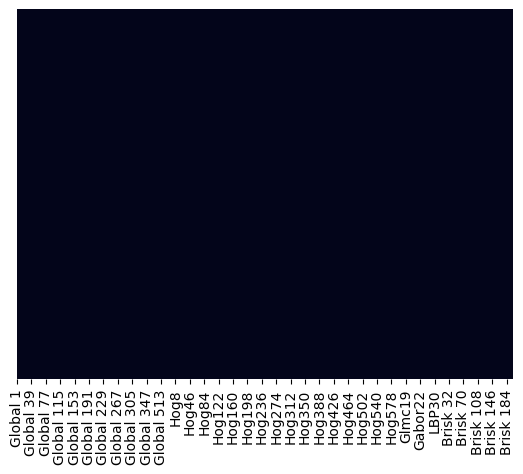

In [292]:
import seaborn as sns
sns.heatmap(x.isna(), yticklabels=False, cbar=False)

In [293]:
x.columns[x.isna().sum() > 0]

Index([], dtype='object')

In [294]:
# Splitting the data into Training set & Testing set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)

In [295]:
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')

print(f'x_test shape: {x_test.shape}')
print(f'y_test shape: {y_test.shape}')

x_train shape: (3715, 1309)
y_train shape: (3715,)
x_test shape: (929, 1309)
y_test shape: (929,)


# Training classifiers

In [296]:
# Convert labels to the appropriate data type
labelencoder = LabelEncoder()
y_true = labelencoder.fit_transform(y_test)

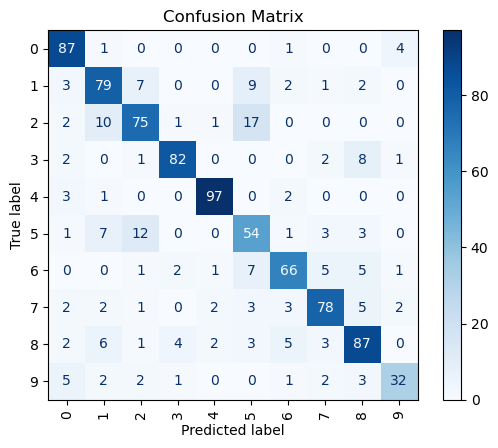

Classifier: Logistic Regression
Accuracy: 79.33%
Precision: 79.70
Recall: 79.33
F1-Score: 79.38
AUC: 96.60
Computational Time: 9.0719 seconds
------------------------------


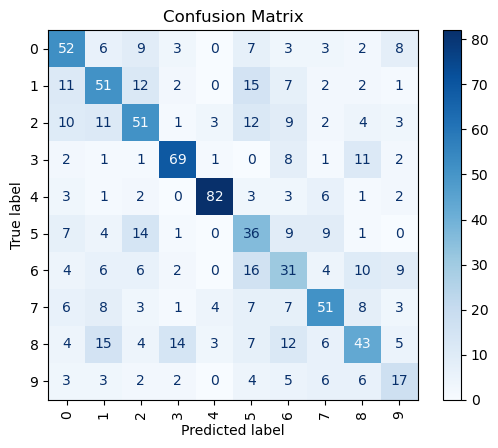

Classifier: Decision Trees
Accuracy: 51.99%
Precision: 53.05
Recall: 51.99
F1-Score: 52.32
AUC: 72.84
Computational Time: 9.6917 seconds
------------------------------


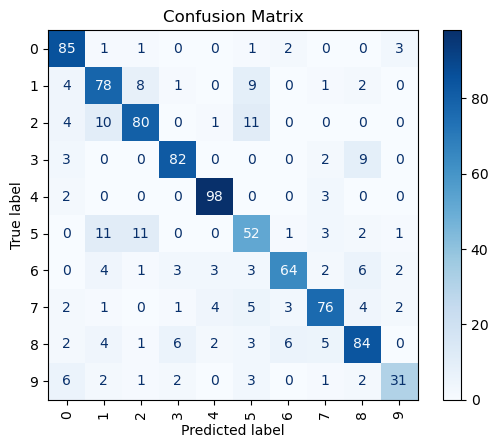

Classifier: Support Vector Machines (SVM)
Accuracy: 78.58%
Precision: 78.80
Recall: 78.58
F1-Score: 78.53
AUC: 97.20
Computational Time: 17.2323 seconds
------------------------------


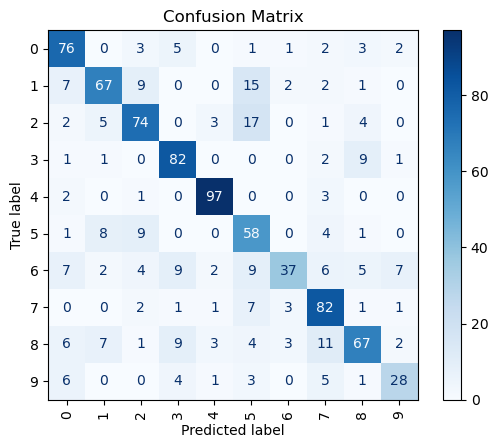

Classifier: Random Forest
Accuracy: 71.91%
Precision: 73.02
Recall: 71.91
F1-Score: 71.45
AUC: 95.86
Computational Time: 109.8200 seconds
------------------------------


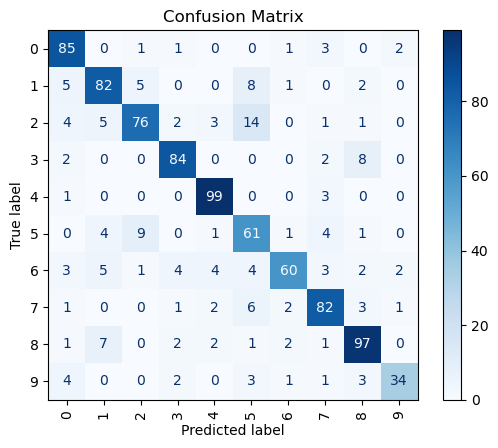

Classifier: LightGBM
Accuracy: 81.81%
Precision: 82.29
Recall: 81.81
F1-Score: 81.74
AUC: 98.18
Computational Time: 86.5657 seconds
------------------------------


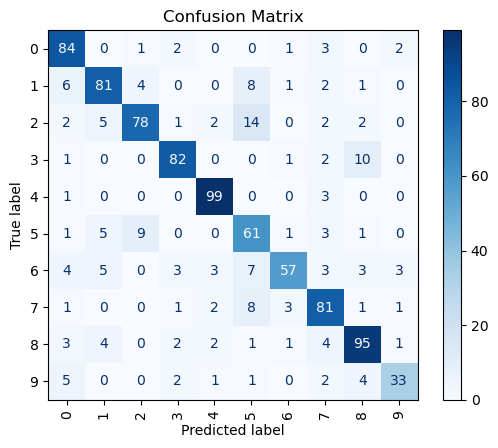

Classifier: XGBoost
Accuracy: 80.84%
Precision: 81.52
Recall: 80.84
F1-Score: 80.80
AUC: 97.78
Computational Time: 274.6789 seconds
------------------------------


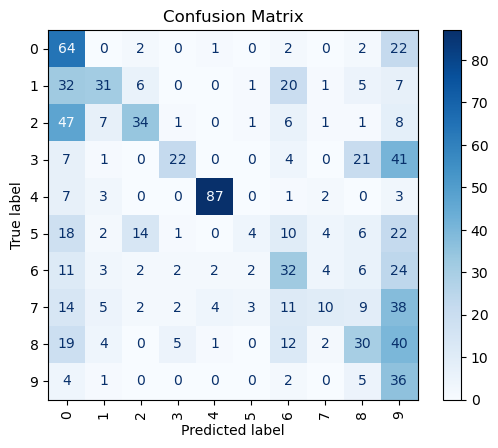

Classifier: Naive Bayes
Accuracy: 37.67%
Precision: 48.07
Recall: 37.67
F1-Score: 36.98
AUC: 79.05
Computational Time: 0.1627 seconds
------------------------------


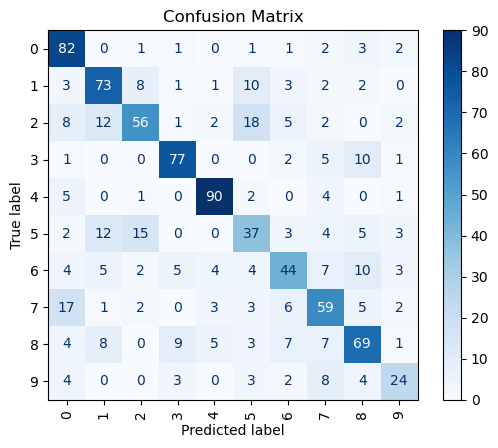

Classifier: K-Nearest Neighbors (KNN)
Accuracy: 65.77%
Precision: 65.70
Recall: 65.77
F1-Score: 65.35
AUC: 92.41
Computational Time: 0.0349 seconds
------------------------------


In [297]:
# Create a dictionary of classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000000),
    'Decision Trees': DecisionTreeClassifier(),
    'Support Vector Machines (SVM)': SVC(probability=True,C=0.028265220878869624, gamma=0.046124850082831514, kernel='linear'),
    'Random Forest': RandomForestClassifier(n_estimators=500,random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=500,random_state=42),
    'XGBoost': XGBClassifier(n_estimators=500, random_state=42),
    # 'CatBoost': CatBoostClassifier(),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors (KNN)': KNeighborsClassifier(metric='manhattan',n_neighbors=9, weights='distance')
    
    
    
}

# Initialize lists to store results
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
auc_scores = []
computational_times = []

# Loop through the classifiers and fit them to dataset
for name, classifier in classifiers.items():
    start_time = time.time()

    # Training models
    classifier.fit(x_train, y_train)  
    end_time = time.time()
    computational_time = end_time - start_time
    computational_times.append(computational_time)
    
    # Produce predictions
    y_pred = classifier.predict(x_test)  
    
   # Evaluate and print the performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')  # Change 'weighted' to your preferred average
    recall = recall_score(y_test, y_pred, average='weighted')  # Change 'weighted' to your preferred average
    f1 = f1_score(y_test, y_pred, average='weighted')  # Change 'weighted' to your preferred average
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=labelencoder.classes_)
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labelencoder.classes_)
    disp.plot(cmap=plt.cm.Blues, values_format="d")
    plt.xticks(rotation=90)
    plt.title("Confusion Matrix")
    plt.show()
 
    # Calculate AUC
    if hasattr(classifier, "predict_proba"):
        # Probability of positive class
        y_pred_proba = classifier.predict_proba(x_test)  
    
        # Calculate AUC for multiclass classification
        auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')  # Choose 'ovo' or 'ovr'
    else:
        # Use decision_function for classifiers without predict_proba
        y_pred_proba = classifier.decision_function(x_test)  
        
        # Calculate AUC for multiclass classification
        auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')  # Choose 'ovo' or 'ovr'
    
    auc_scores.append(auc)  
    
    
    print(f"Classifier: {name}")
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}")
    print(f"Recall: {recall*100:.2f}")
    print(f"F1-Score: {f1*100:.2f}")
    print(f"AUC: {auc*100:.2f}")
    print(f"Computational Time: {computational_time:.4f} seconds")
    print("------------------------------")

# Create a dataframe to summarize the results
results_df = pd.DataFrame({
    'Classifier': list(classifiers.keys()),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores,
    'AUC': auc_scores,
    'Computational Time (seconds)': computational_times
})

In [298]:
results_df

,Classifier,Accuracy,Precision,Recall,F1-Score,AUC,Computational Time (seconds)
0,Logistic Regression,0.793326,0.796966,0.793326,0.793769,0.966030,9.071899
1,Decision Trees,0.519914,0.530501,0.519914,0.523218,0.728431,9.691666
2,Support Vector Machines (SVM),0.785791,0.788020,0.785791,0.785287,0.971954,17.232266
3,Random Forest,0.719053,0.730230,0.719053,0.714465,0.958558,109.819992
4,LightGBM,0.818084,0.822907,0.818084,0.817364,0.981816,86.565703
5,XGBoost,0.808396,0.815242,0.808396,0.808034,0.977818,274.678856
6,Naive Bayes,0.376749,0.480734,0.376749,0.369787,0.790514,0.162740
7,K-Nearest Neighbors (KNN),0.657696,0.656966,0.657696,0.653504,0.924104,0.034905


# Data reduction Using Random Forest

In [299]:
# create the model - RandomForest
RF = RandomForestClassifier(n_estimators=500,random_state=402)
                     

# fit the training data to the model
RF.fit(x_train, y_train)

RandomForestClassifier(n_estimators=500, random_state=402)

In [300]:
# Predict the labels for the test data
RF_y_pred = RF.predict(x_test)

# Compare predicted labels with actual labels
RF_accuracy = accuracy_score(y_test, RF_y_pred)

# Print the accuracy
print(" RF Classifier Test Accuracy: {:.2%}".format(RF_accuracy))

 RF Classifier Test Accuracy: 72.77%


In [301]:
# Get feature importances
features_list = list(x_train.columns)
feature_imp = pd.Series(RF.feature_importances_, index=features_list).sort_values(ascending=False)

# Display all feature importances
print(feature_imp)

Glmc37        0.008474
Global 526    0.008419
Glmc27        0.007857
Glmc32        0.007794
Glmc42        0.007762
                ...   
Global 312    0.000000
Global 310    0.000000
Global 296    0.000000
Global 303    0.000000
Global 302    0.000000
Length: 1309, dtype: float64


In [302]:
# # Plot the feature importances
# plt.figure(figsize=(25, 8))
# feature_imp.plot(kind='bar')
# plt.title("Feature Importances")
# plt.ylabel("Importance")
# plt.show()


In [303]:
# Select the top 200 features
top_features = feature_imp.head(200).index
x_train_top100 = x_train[top_features]
x_test_top100 = x_test[top_features]

### Training classifiers After data reduction

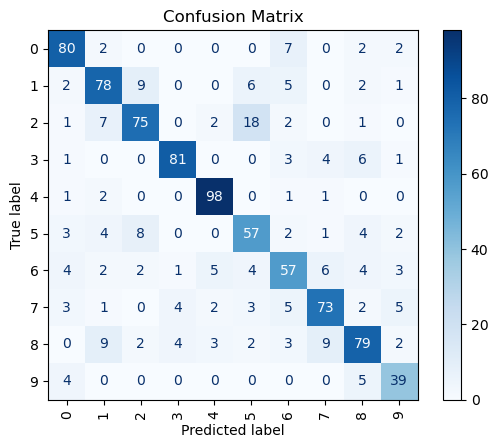

Classifier: Logistic Regression
Accuracy: 77.18%
Precision: 77.30
Recall: 77.18
F1-Score: 77.14
AUC: 96.47
Computational Time: 1.9414 seconds
------------------------------


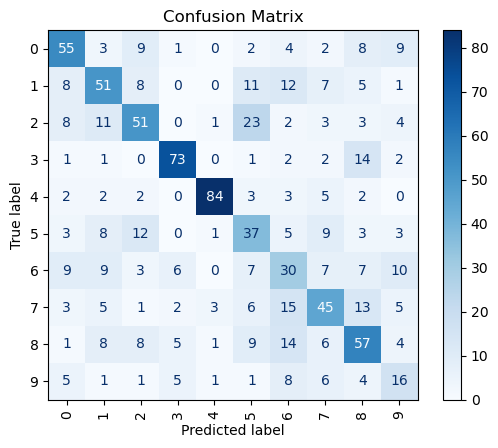

Classifier: Decision Trees
Accuracy: 53.71%
Precision: 54.95
Recall: 53.71
F1-Score: 54.22
AUC: 73.62
Computational Time: 1.6968 seconds
------------------------------


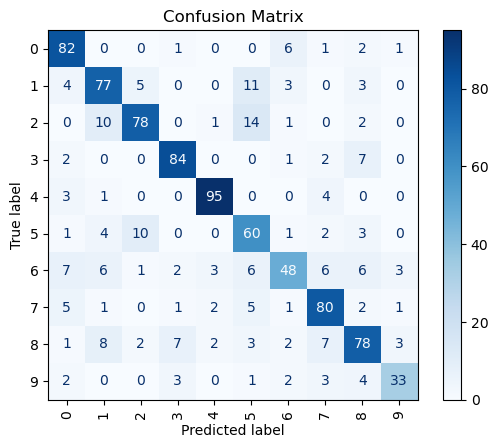

Classifier: Support Vector Machines (SVM)
Accuracy: 76.96%
Precision: 77.29
Recall: 76.96
F1-Score: 76.82
AUC: 96.40
Computational Time: 2.2233 seconds
------------------------------


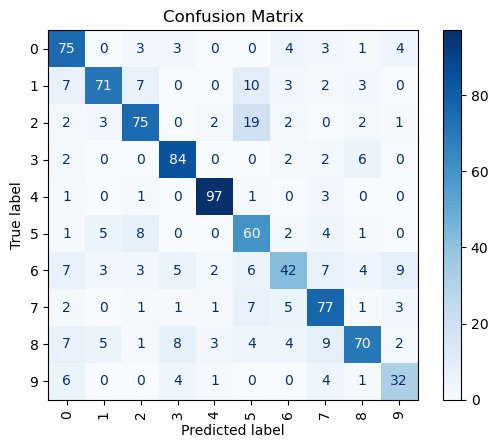

Classifier: Random Forest
Accuracy: 73.52%
Precision: 74.16
Recall: 73.52
F1-Score: 73.30
AUC: 95.98
Computational Time: 49.1400 seconds
------------------------------


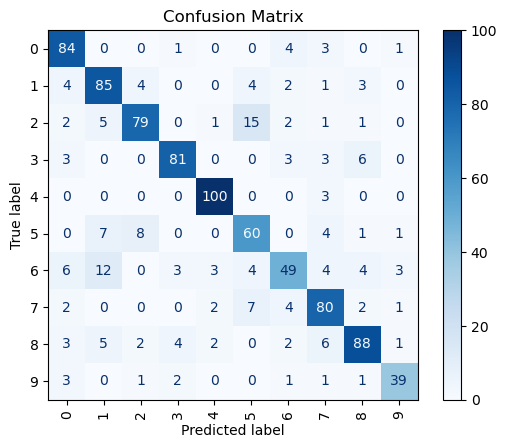

Classifier: LightGBM
Accuracy: 80.19%
Precision: 80.36
Recall: 80.19
F1-Score: 80.01
AUC: 97.54
Computational Time: 28.1284 seconds
------------------------------


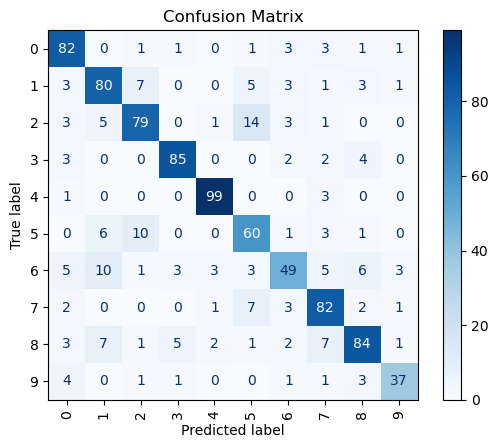

Classifier: XGBoost
Accuracy: 79.33%
Precision: 79.43
Recall: 79.33
F1-Score: 79.15
AUC: 97.48
Computational Time: 60.2609 seconds
------------------------------


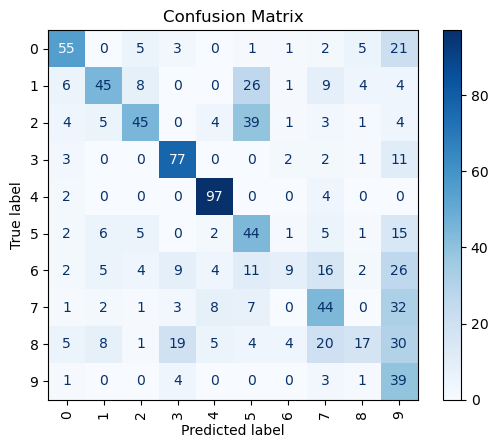

Classifier: Naive Bayes
Accuracy: 50.81%
Precision: 56.41
Recall: 50.81
F1-Score: 49.43
AUC: 86.33
Computational Time: 0.0509 seconds
------------------------------


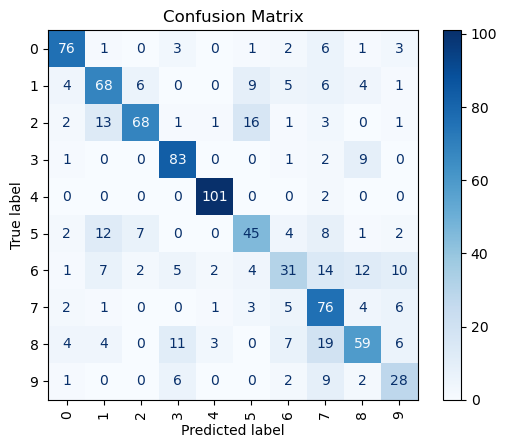

Classifier: K-Nearest Neighbors (KNN)
Accuracy: 68.35%
Precision: 68.84
Recall: 68.35
F1-Score: 67.90
AUC: 93.12
Computational Time: 0.0079 seconds
------------------------------


In [304]:
# Create a dictionary of classifiers
classifiers1 = {
    'Logistic Regression': LogisticRegression(max_iter=1000000),
    'Decision Trees': DecisionTreeClassifier(),
    'Support Vector Machines (SVM)': SVC(probability=True,C=0.028265220878869624, gamma=0.046124850082831514, kernel='linear'),
    'Random Forest': RandomForestClassifier(n_estimators=500,random_state=1101),
    'LightGBM': LGBMClassifier(n_estimators=1500,random_state=1101),
    'XGBoost': XGBClassifier(n_estimators=500, random_state=1101),
    # 'CatBoost': CatBoostClassifier(),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors (KNN)': KNeighborsClassifier(metric='manhattan', n_neighbors=9, weights='distance')
    
    
    
}

# Initialize lists to store results
accuracy_scores1 = []
precision_scores1 = []
recall_scores1 = []
f1_scores1 = []
auc_scores1 = []
computational_times1 = []

# Loop through the classifiers and fit them to dataset
for name, classifier in classifiers1.items():
    start_time = time.time()

    # Training models
    classifier.fit(x_train_top100, y_train)  
    end_time = time.time()
    computational_time = end_time - start_time
    computational_times1.append(computational_time)
    
    # Produce predictions
    y_pred = classifier.predict(x_test_top100)  
    
   # Evaluate and print the performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')  
    recall = recall_score(y_test, y_pred, average='weighted')  
    f1 = f1_score(y_test, y_pred, average='weighted') 
    accuracy_scores1.append(accuracy)
    precision_scores1.append(precision)
    recall_scores1.append(recall)
    f1_scores1.append(f1)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=labelencoder.classes_)
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labelencoder.classes_)
    disp.plot(cmap=plt.cm.Blues, values_format="d")
    plt.xticks(rotation=90)
    plt.title("Confusion Matrix")
    plt.show()
   
    # Calculate AUC
    if hasattr(classifier, "predict_proba"):
        # Probability of positive class
        y_pred_proba = classifier.predict_proba(x_test_top100)  
    
        # Calculate AUC for multiclass classification
        auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr') 
    else:
        # Use decision_function for classifiers without predict_proba
        y_pred_proba = classifier.decision_function(x_test_top100)  
        
        # Calculate AUC for multiclass classification
        auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr') 
    
    auc_scores1.append(auc)  
    
    
    print(f"Classifier: {name}")
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}")
    print(f"Recall: {recall*100:.2f}")
    print(f"F1-Score: {f1*100:.2f}")
    print(f"AUC: {auc*100:.2f}")
    print(f"Computational Time: {computational_time:.4f} seconds")
    print("------------------------------")

# Create a dataframe to summarize the results
results_df1 = pd.DataFrame({
    'Classifier': list(classifiers1.keys()),
    'Accuracy': accuracy_scores1,
    'Precision': precision_scores1,
    'Recall': recall_scores1,
    'F1-Score': f1_scores1,
    'AUC': auc_scores1,
    'Computational Time (seconds)': computational_times1
})

In [305]:
results_df1

,Classifier,Accuracy,Precision,Recall,F1-Score,AUC,Computational Time (seconds)
0,Logistic Regression,0.771798,0.772998,0.771798,0.771381,0.964671,1.941442
1,Decision Trees,0.537137,0.549517,0.537137,0.542160,0.736199,1.696770
2,Support Vector Machines (SVM),0.769645,0.772941,0.769645,0.768213,0.964037,2.223252
3,Random Forest,0.735199,0.741626,0.735199,0.733043,0.959775,49.139956
4,LightGBM,0.801938,0.803596,0.801938,0.800144,0.975441,28.128430
5,XGBoost,0.793326,0.794271,0.793326,0.791534,0.974818,60.260924
6,Naive Bayes,0.508073,0.564073,0.508073,0.494254,0.863279,0.050867
7,K-Nearest Neighbors (KNN),0.683531,0.688397,0.683531,0.679016,0.931217,0.007950


# Testing the best classifier

In [306]:
# create the model - LightGBM
LGBM = LGBMClassifier(n_estimators=1500,random_state=1)
                     

# fit the training data to the model
LGBM.fit(x_train_top100, y_train)

LGBMClassifier(n_estimators=1500, random_state=1)

In [307]:
# Predict the labels for the test data
LGBM_y_pred = LGBM.predict(x_test_top100)

# Compare predicted labels with actual labels
LGBM_accuracy = accuracy_score(y_test, LGBM_y_pred)

# Print the accuracy
print(" LGBMClassifier Test Accuracy: {:.2%}".format(LGBM_accuracy))

 LGBMClassifier Test Accuracy: 80.19%


In [308]:
# Predict the labels for the train data
train_y_pred = LGBM.predict(x_train_top100)

# Compare predicted labels with actual labels
train_accuracy = accuracy_score(y_train, train_y_pred)

# Print the accuracy
print(" LGBMClassifier Train Accuracy: {:.2%}".format(train_accuracy))

 LGBMClassifier Train Accuracy: 100.00%


##  Hyperparameter Tuning

In [160]:
from sklearn import svm
from scipy.stats import uniform

# Define the SVM model
svm_model = svm.SVC()

# Define the hyperparameter grid
hyperparameter_grid = {'C': uniform(loc=0, scale=4),
                       'gamma': uniform(loc=0, scale=2),
                       'kernel': ['linear', 'rbf']}

# Perform Random Search
random_search = RandomizedSearchCV(estimator=svm_model,
                                   param_distributions=hyperparameter_grid,
                                   n_iter=10,
                                   cv=5,
                                   random_state=42,
                                   scoring='accuracy',
                                   n_jobs=-1)

# Fit the random search to the training data
random_search.fit(x_train, y_train)

# Print the best hyperparameters and accuracy score
print("Best Hyperparameters: ", random_search.best_params_)
print("Best Accuracy Score: ", random_search.best_score_)

# Evaluate the model with the best hyperparameters on the test set
best_model = random_search.best_estimator_
test_accuracy = best_model.score(x_test, y_test)
print("Test Accuracy: ", test_accuracy)

Best Hyperparameters:  {'C': 0.028265220878869624, 'gamma': 0.046124850082831514, 'kernel': 'linear'}
Best Accuracy Score:  0.7647375504710633
Test Accuracy:  0.7857911733046287


In [ ]:
# Define the parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create the Random Forest classifier
rf_classifier = RandomForestClassifier()

# Perform grid search to find the best hyperparameters
rf_grid_search = GridSearchCV(rf_classifier, rf_param_grid, cv=5, scoring='accuracy')
rf_grid_search.fit(x_train, y_train)

# Print the best hyperparameters and best score for Random Forest
print("Best Hyperparameters for Random Forest: ", rf_grid_search.best_params_)
print("Best Score for Random Forest: ", rf_grid_search.best_score_)

# Evaluate the model on the test set with the best hyperparameters
best_rf_model = rf_grid_search.best_estimator_
rf_accuracy = best_rf_model.score(x_test, y_test)
print("Test Accuracy for Random Forest: ", rf_accuracy)


In [162]:
# Define the parameter grid for grid search
param_grid = {
    # Possible values for the number of neighbors (K)
    'n_neighbors': [3, 5, 7,9,11],  
    # Possible weight options for neighbors
    'weights': ['uniform', 'distance'],  
    # Possible distance metrics
    'metric': ['euclidean', 'manhattan'] 
}

# Create the KNN classifier
knn = KNeighborsClassifier()

# Perform grid search to find the best hyperparameters
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

# Print the best hyperparameters and best score
print("Best Hyperparameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)

# Evaluate the model on the test set with the best hyperparameters
best_model = grid_search.best_estimator_
accuracy = best_model.score(x_test, y_test)
accuracy1 = accuracy_score(y_test, y_pred)
print("Test Accuracy: ", accuracy)


Best Hyperparameters:  {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best Score:  0.6379542395693136
Test Accuracy:  0.6576964477933261
